In [ ]:
# a) Import data & info()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
nycgreen = pd.read_parquet("/content/green_tripdata_2021-06 (1).parquet")


In [ ]:
# Display info
nycgreen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86737 entries, 0 to 86736
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               86737 non-null  int64         
 1   lpep_pickup_datetime   86737 non-null  datetime64[us]
 2   lpep_dropoff_datetime  86737 non-null  datetime64[us]
 3   store_and_fwd_flag     54441 non-null  object        
 4   RatecodeID             54441 non-null  float64       
 5   PULocationID           86737 non-null  int64         
 6   DOLocationID           86737 non-null  int64         
 7   passenger_count        54441 non-null  float64       
 8   trip_distance          86737 non-null  float64       
 9   fare_amount            86737 non-null  float64       
 10  extra                  86737 non-null  float64       
 11  mta_tax                86737 non-null  float64       
 12  tip_amount             86737 non-null  float64       
 13  t

In [ ]:
# b) Drop ehail_fee and fare_amount columns
nycgreen = nycgreen.drop(["ehail_fee", "fare_amount"], axis=1)

In [ ]:
# c) Calculate trip_duration in minutes
nycgreen["trip_duration"] = (nycgreen["lpep_dropoff_datetime"] - nycgreen["lpep_pickup_datetime"]).dt.total_seconds() / 60

In [ ]:
#d) Extract weekday from dropoff datetime
nycgreen["weekday"] = nycgreen["lpep_dropoff_datetime"].dt.day_name()
print(nycgreen["weekday"].value_counts())



weekday
Wednesday    15389
Tuesday      14852
Thursday     12843
Friday       12535
Monday       11512
Saturday     11046
Sunday        8560
Name: count, dtype: int64


In [ ]:
# e) Extract hour from dropoff datetime
nycgreen["hourofday"] = nycgreen["lpep_dropoff_datetime"].dt.hour
print(nycgreen["hourofday"].value_counts())

hourofday
10    6466
11    6277
12    6206
9     6192
15    5905
13    5772
14    5685
16    5625
18    5499
17    5422
8     4856
19    4776
7     3242
20    3158
21    2433
22    1992
23    1789
6     1657
0     1245
1      701
5      695
2      441
4      423
3      280
Name: count, dtype: int64


In [ ]:
# f) Missing Values Imputation
# Numeric columns - impute with median
num_cols = ['trip_distance', 'extra', 'mta_tax', 'tip_amount',
            'tolls_amount', 'improvement_surcharge', 'congestion_surcharge',
            'trip_duration', 'passenger_count']
for col in num_cols:
    nycgreen[col] = nycgreen[col].fillna(nycgreen[col].median())


In [ ]:
# Object columns - impute with mode
obj_cols = ['store_and_fwd_flag', 'RatecodeID', 'payment_type', 'trip_type']
for col in obj_cols:
    nycgreen[col] = nycgreen[col].fillna(nycgreen[col].mode()[0])



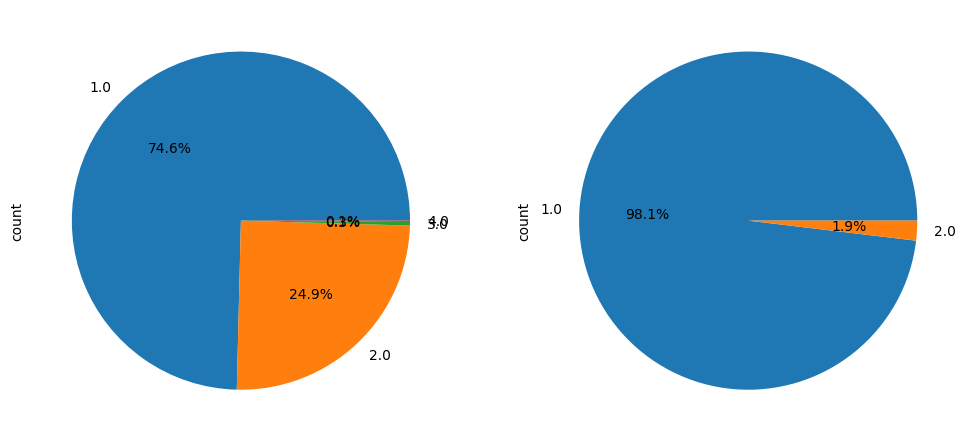

In [ ]:
# g) Pie diagrams
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
nycgreen['payment_type'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0])
nycgreen['trip_type'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1])
plt.show()



In [ ]:
# h) Groupby average total_amount by weekday
print(nycgreen.groupby('weekday')['total_amount'].mean())




weekday
Friday       23.835968
Monday       23.495116
Saturday     23.174901
Sunday       23.952779
Thursday     23.836405
Tuesday      23.535459
Wednesday    23.521304
Name: total_amount, dtype: float64


In [ ]:
# i) Groupby average total_amount by payment_type
print(nycgreen.groupby('payment_type')['total_amount'].mean())


payment_type
1.0    27.062321
2.0    13.623382
3.0     3.331325
4.0    10.616505
Name: total_amount, dtype: float64


In [ ]:
# j) Groupby average tip_amount by weekday
print(nycgreen.groupby('weekday')['tip_amount'].mean())


weekday
Friday       1.089552
Monday       0.957576
Saturday     1.120177
Sunday       1.174345
Thursday     1.059799
Tuesday      0.970683
Wednesday    1.018584
Name: tip_amount, dtype: float64


In [ ]:
# k) Groupby average tip_amount by payment_type
print(nycgreen.groupby('payment_type')['tip_amount'].mean())


payment_type
1.0    1.403324
2.0    0.000000
3.0   -0.021656
4.0    0.000000
Name: tip_amount, dtype: float64


In [ ]:
# l) ANOVA test for total_amount across trip_types
from scipy.stats import f_oneway
groups = [nycgreen[nycgreen['trip_type'] == val]['total_amount'] for val in nycgreen['trip_type'].unique()]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(29.561439953772894), pvalue=np.float64(5.431769548616776e-08))

In [ ]:
# m) ANOVA test for total_amount across weekdays
groups = [nycgreen[nycgreen['weekday'] == day]['total_amount'] for day in nycgreen['weekday'].unique()]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(2.771545699148357), pvalue=np.float64(0.010751891579627594))

In [ ]:
# n) Chi-square test for association between trip_type and payment_type
from scipy.stats import chi2_contingency
contingency = pd.crosstab(nycgreen['trip_type'], nycgreen['payment_type'])
chi2_contingency(contingency)


Chi2ContingencyResult(statistic=np.float64(396.22171327285906), pvalue=np.float64(1.457301207887198e-85), dof=3, expected_freq=array([[6.34906400e+04, 2.12080223e+04, 2.96286383e+02, 1.01051316e+02],
       [1.22436002e+03, 4.08977680e+02, 5.71361703e+00, 1.94868395e+00]]))

In [ ]:
# o) Numeric variables correlation analysis
numeric_df = nycgreen[num_cols + ['total_amount']]
corr_matrix = numeric_df.corr()
print(corr_matrix)


                       trip_distance     extra   mta_tax  tip_amount  \
trip_distance               1.000000  0.040166 -0.049851   -0.011278   
extra                       0.040166  1.000000 -0.668102   -0.224727   
mta_tax                    -0.049851 -0.668102  1.000000    0.155899   
tip_amount                 -0.011278 -0.224727  0.155899    1.000000   
tolls_amount                0.010211  0.122465 -0.145348    0.015698   
improvement_surcharge       0.002409  0.057256  0.130682    0.022236   
congestion_surcharge       -0.017128 -0.127584  0.333225    0.259611   
trip_duration               0.010518  0.006154 -0.007631    0.011372   
passenger_count            -0.009247 -0.123653  0.165436    0.027500   
total_amount                0.021727  0.326968 -0.363236    0.152706   

                       tolls_amount  improvement_surcharge  \
trip_distance              0.010211               0.002409   
extra                      0.122465               0.057256   
mta_tax              

In [ ]:
# p) Dummy encode object variables
nycgreen = pd.get_dummies(nycgreen, columns=obj_cols + ['weekday', 'hourofday'])


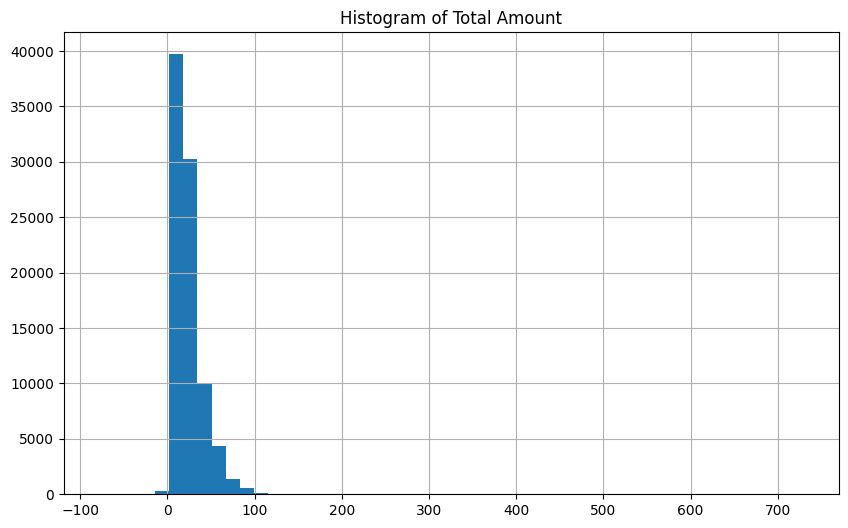

In [ ]:
# q) Analyze dependent variable total_amount
# Histogram
plt.figure(figsize=(10, 6))
nycgreen['total_amount'].hist(bins=50)
plt.title('Histogram of Total Amount')
plt.show()


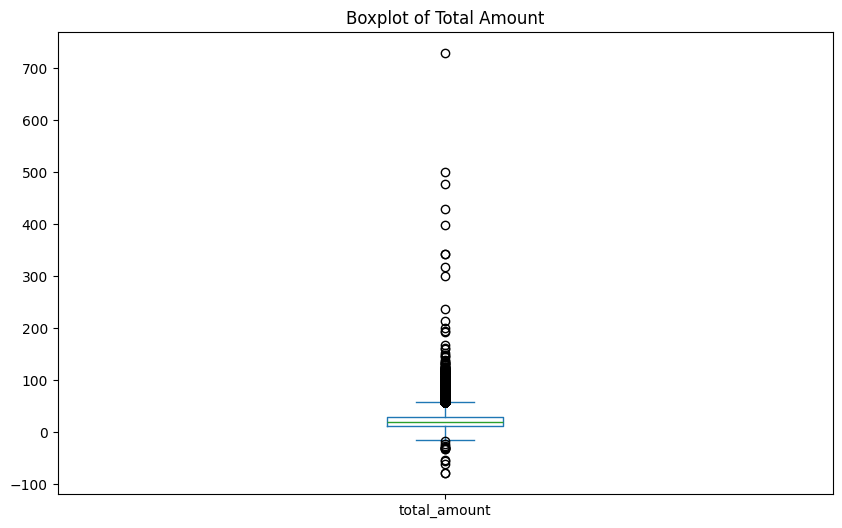

In [ ]:
# Boxplot
plt.figure(figsize=(10, 6))
nycgreen['total_amount'].plot.box()
plt.title('Boxplot of Total Amount')
plt.show()

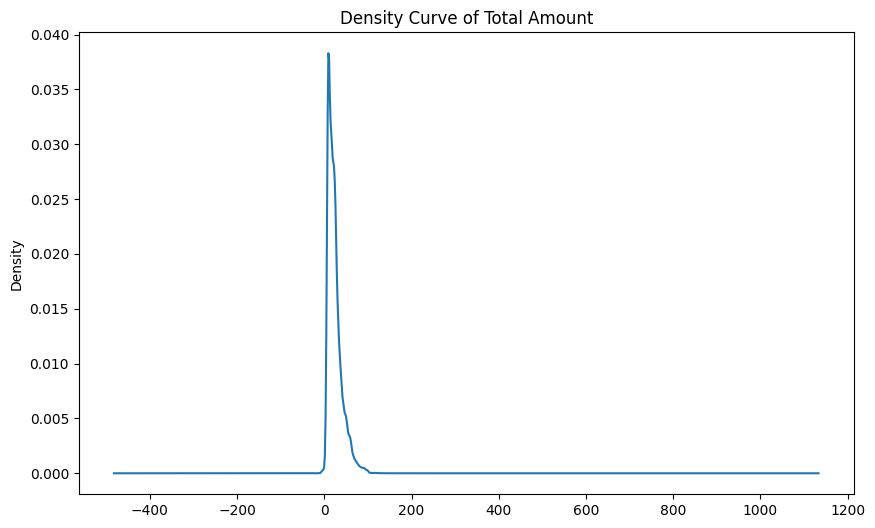

In [ ]:
# Density curve
plt.figure(figsize=(10, 6))
nycgreen['total_amount'].plot.kde()
plt.title('Density Curve of Total Amount')
plt.show()

In [ ]:
# t) Build regression models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Prepare data
X = nycgreen.drop(['total_amount', 'lpep_pickup_datetime', 'lpep_dropoff_datetime'], axis=1)
y = nycgreen['total_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 1. Multiple Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, y_pred))


Linear Regression R2: 0.4586312136855306


In [ ]:
# 2. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, y_pred))


Decision Tree R2: 0.7349136577796673


In [ ]:
# 3. Random Forest with 100 trees
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred))


Random Forest R2: 0.8149599119705014


In [ ]:
# 4. Gradient Boosting with 100 trees
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
print("Gradient Boosting R2:", r2_score(y_test, y_pred))

Gradient Boosting R2: 0.8015726766694191
